# CS448 - Lab 1: Forward and Inverse STFT

The purpose of this lab is to familiarize you with taking a sound to the time/frequency domain and back. You will code a spectrogram routine, its inverse, and then run some examples to see the effects of various parameters when performing such analyses. Although you can find existing functions to perform some of these calculations, you will have to develop your own version from scratch. This will allow you to perform some more complex processing later in the semester, and of course it will also give you a deeper understanding of how things work.

You will likely reuse a lot of this code in future labs, so this is not one of the labs to skip!

## Part 1. The Forward Transform

You need to design a function that uses five different arguments as follows:
```
	stft_output = stft( input_sound, dft_size, hop_size, window)
		input_sound is a 1d array that contains an input sound.
		dft_size is the DFT point size that you will use for this analysis.
		hop_size is the number of samples that your analysis frame will advance.
		window is a vector containing the analysis window that you will be using.
```

To complete this you need to perform the following steps:

- You need to segment the input array as shorter frames which are ```dft_size``` samples long. Each frame will start ```hop_size``` samples after the beginning of the previous one. In practice, ```hop_size``` will be smaller than ```dft_size```, usually by a factor of 2 or 4. Feel free to add some zeros at the beginning and/or end of the input so that you have enough samples to compose the last frame at the desired length.

- You will then need to compute the Discrete Fourier Transform (DFT) of each frame. For each input frame you will get a complex-valued vector containing its spectrum. Take all of these vectors and concatenate them as columns of a matrix. The ```{i,j}``` element of this matrix will contain the coefficient for frequency ```i``` at input frame ```j```. Note that there is a variety of Fourier options in numpy. Since we will be using real-valued signals you should use the ```fft.rfft``` routine.

- You might notice that by doing only the above the output is a little noisy-looking. This is because we are not using an analysis window. In order to apply a window, before you apply the DFT routine, you need to multiply each analysis frame with a function that smoothly tapers the edges down to zero. This function will be provided as the function input ```window```, which will have to have the same length as the analysis frames (i.e. ```dft_size``` samples). Typical window shapes are the triangle window (goes from 0 to 1 to 0), the Hann window (see the incorrectly-named function ```hanning```), the Hamming window (```hamming```), and the Kaiser window (```kaiser```).

You should now have a complete forward Short-Time Fourier Transform routine.  Try it on the following example sounds: ```80s.wav```, ```speech.wav```, and ```piano.wav```, and plot the magnitude of the result (i.e., plot it as an image). Try to find the best function parameters that allow you to see what’s going on in the input sounds. You want to get a feel of what it means to change the DFT size, the hop size, and the window. Plot some results that demonstrate the effect of these parameters.  As a rough guide, traditionally the hop size is 1/2, 1/4 or 1/8, of the DFT size, and historically the DFT size is almost always chosen to be a power of two (it's faster than otherwise).

Often, such plots lack significant contrast to make a good visualization. A good idea is to plot the log value of the magnitudes (beware of zeros), or to raise them to a small power, e.g. 0.3. This will create better looking plots where smaller differences are more visible. A good colormap is also essential, have a look at: [ https://jakevdp.github.io/blog/2014/10/16/how-bad-is-your-colormap/ ] You want to use something with a linear luminance gradient.

Finally, I want you to make sure that the axes in your spectrogram plot are in terms of Hz on the y-axis and seconds on the x-axis.  Knowing the exact range of your data is important, so be careful. I might ask questions about this in the quizzes or exams.

In [37]:
import numpy as np
import soundfile as sf
import matplotlib.pyplot as plt

In [50]:
# Make a sound player function that plays array "x" with a sample rate "rate", and labels it with "label"
def sound_player( x, rate=8000, label=''):
    from IPython.display import display, Audio, HTML
    display( HTML( 
    '<style> table, th, td {border: 0px; }</style> <table><tr><td>' + label + 
    '</td><td>' + Audio( x, rate=rate)._repr_html_()[3:] + '</td></tr></table>'
    ))

11025 11025 16000


Original Drums,Your browser does not support the audio element.


Original Piano,Your browser does not support the audio element.


Original Speech,Your browser does not support the audio element.


(513, 57) (513, 71) (513, 98)


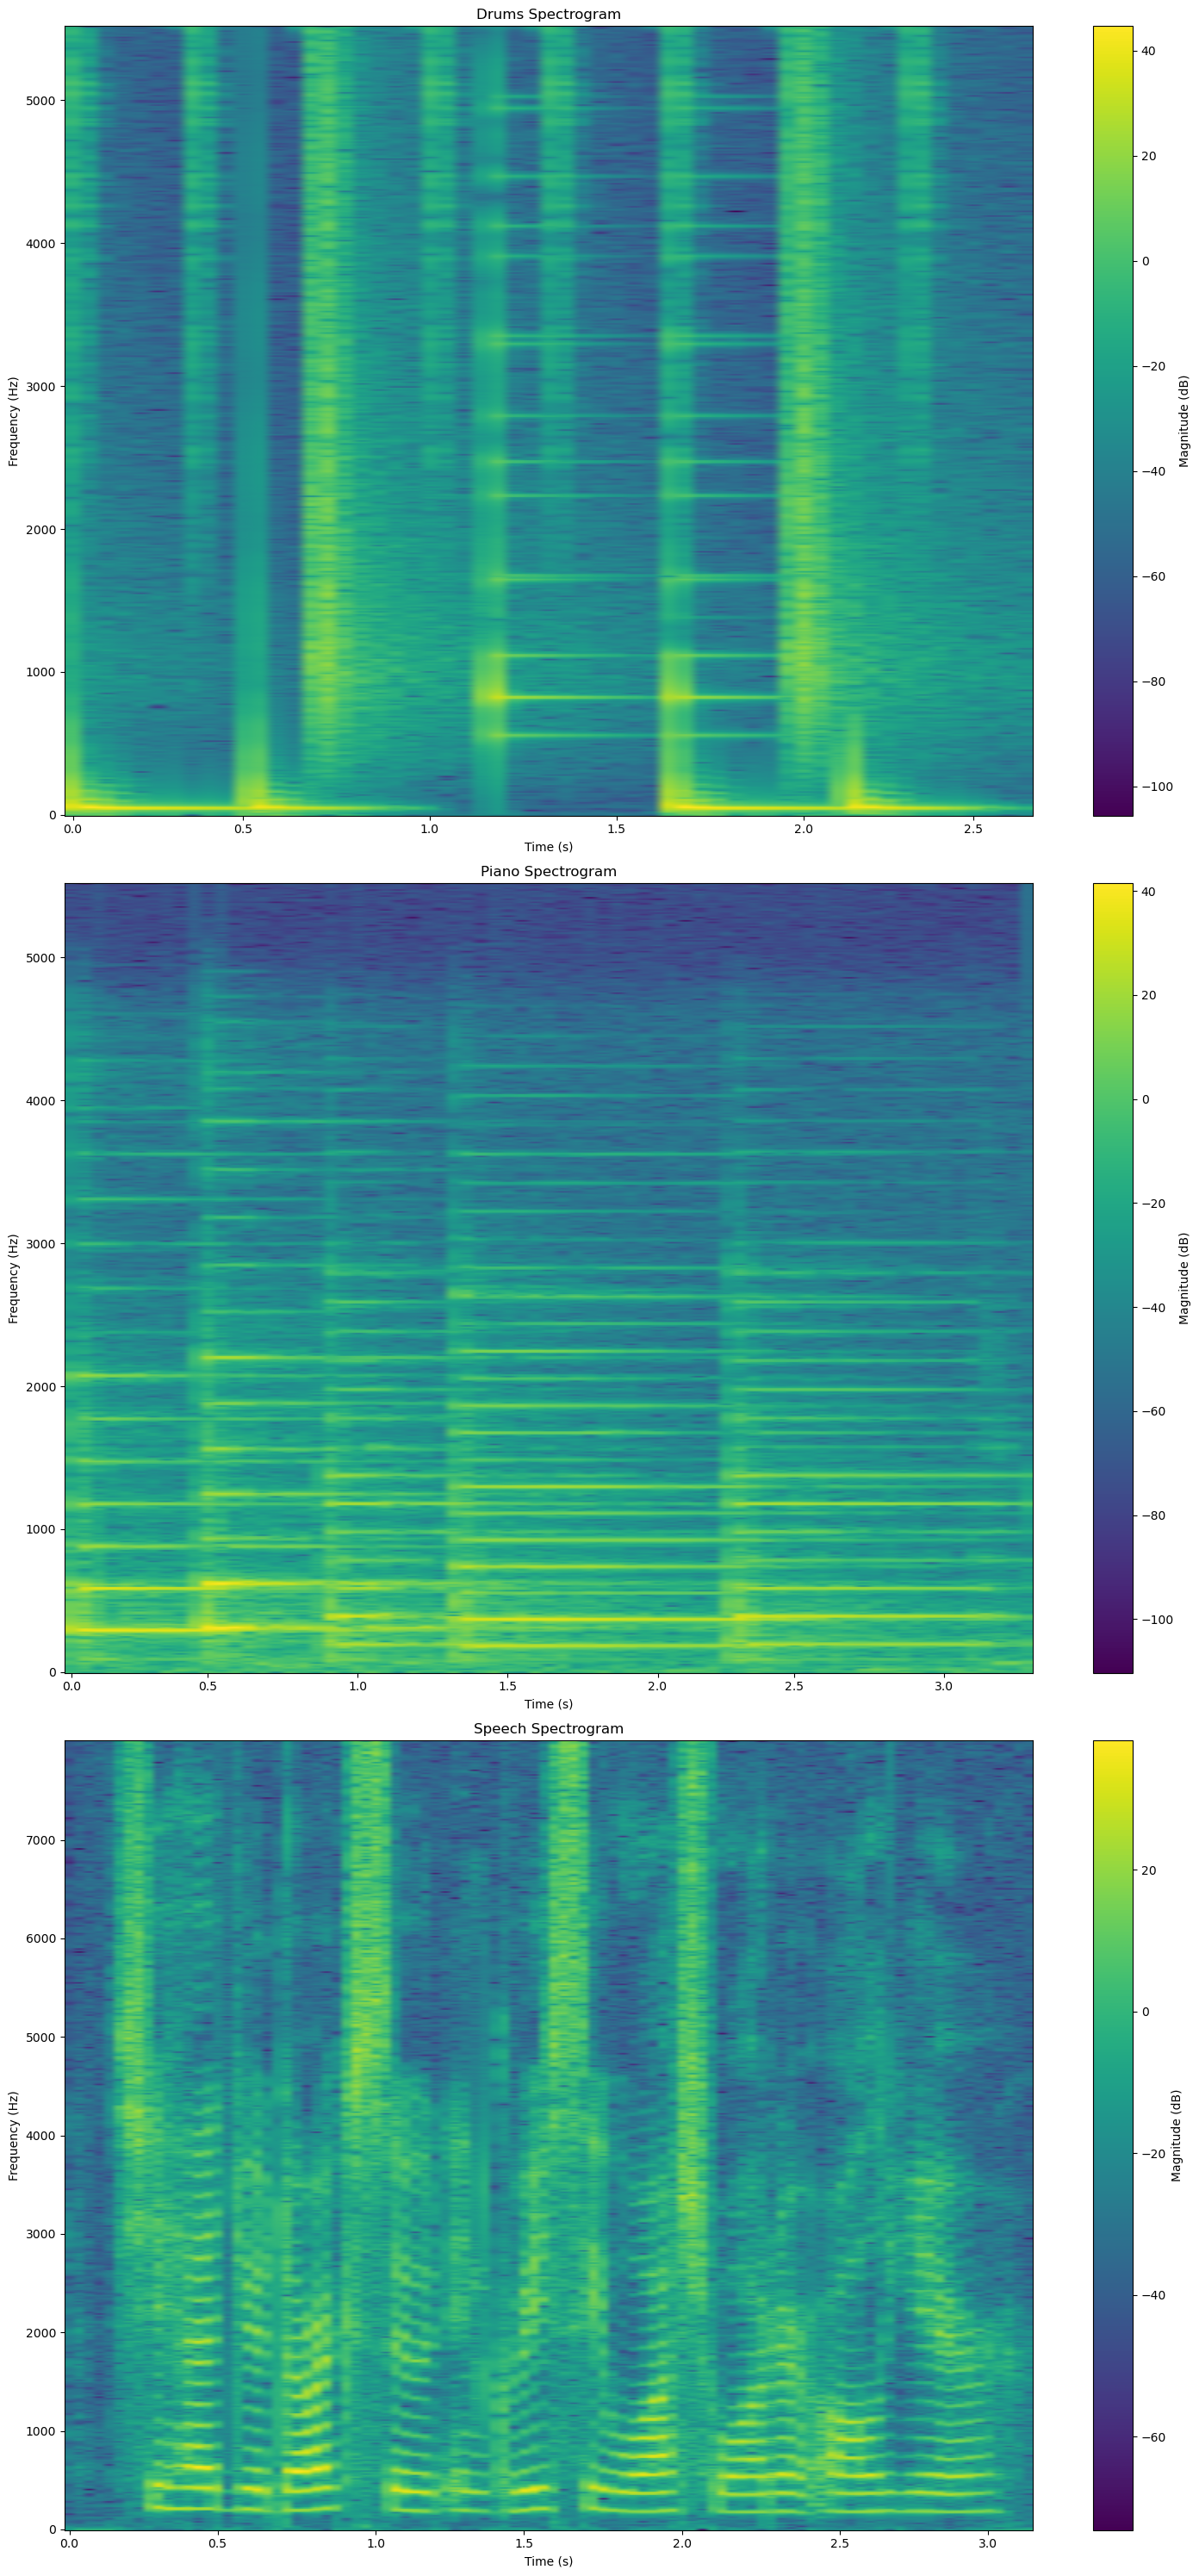

In [106]:
def stft( input_sound, dft_size, hop_size, window):
    """Compute the short-time Fourier transform of a sound.
    Args:
        input_sound: 1D numpy array containing the sound samples
        dft_size: Size of the DFT to compute (number of frequency bins)
        hop_size: Number of samples to advance between successive frames
        window: 1D numpy array containing the analysis window (length = dft_size)
    Returns:
        f: 2D numpy array (frequencies x time) containing the complex-valued STFT
    """
    input_sound_length = len(input_sound)
    num_frames = 1 + (input_sound_length - dft_size) // hop_size
    spectrogram = np.zeros((dft_size // 2 + 1, num_frames), dtype=np.complex64)
    for frame in range(num_frames):
        start = frame * hop_size
        end = start + dft_size
        segment = input_sound[start:end] * window
        spectrum = np.fft.rfft(segment, n=dft_size)
        spectrogram[:, frame] = spectrum

    # Return a complex-valued spectrogram (frequencies x time)    
    return spectrogram
    # # YOUR CODE HERE
    # raise NotImplementedError()

dft_size=1024
hop_size=512

# Load each sound
drums, sr_drum=sf.read('80s.wav')
piano, sr_piano=sf.read('piano.wav')
speech, sr_speech=sf.read('speech.wav')
print(sr_drum, sr_piano, sr_speech)
sound_player(drums, sr_drum, 'Original Drums')
sound_player(piano, sr_piano, 'Original Piano')
sound_player(speech, sr_speech, 'Original Speech')


# zero-pad the beginning and end of each sound by 512 samples
drums_padded = np.pad(drums, (512, 512), mode='constant')
piano_padded = np.pad(piano, (512, 512), mode='constant')
speech_padded = np.pad(speech, (512, 512), mode='constant')

# # YOUR CODE HERE
# raise NotImplementedError()

# STFT them
stft_drums = stft(drums_padded, dft_size, hop_size, np.hanning(dft_size)**.5)
stft_piano = stft(piano_padded, dft_size, hop_size, np.hanning(dft_size)**.5)
stft_speech = stft(speech_padded, dft_size, hop_size, np.hanning(dft_size)**.5)


# # YOUR CODE HERE
# raise NotImplementedError()

# Plot all the spectrograms

print(stft_drums.shape, stft_piano.shape, stft_speech.shape)

xtick_period=0.5  # seconds


plt.figure(figsize=(15, 30))
plt.subplot(3, 1, 1)
plt.title('Drums Spectrogram')
plt.imshow(20 * np.log10(np.abs(stft_drums) + 1e-6), aspect='auto', origin='lower', cmap='viridis')
plt.xticks([(xtick_period*i*sr_drum)//hop_size for i in range(np.int32((drums.shape[0]/sr_drum)/xtick_period)+1)], [xtick_period*i for i in range(np.int32((drums.shape[0]/sr_drum)/xtick_period+1))])
plt.xlabel('Time (s)')
plt.yticks([i/(sr_drum/2)*dft_size/2 for i in range(0, sr_drum//2, 1000)], [i for i in range(0, sr_drum//2, 1000)])
plt.ylabel('Frequency (Hz)')
plt.colorbar(label='Magnitude (dB)')
plt.subplot(3, 1, 2)
plt.title('Piano Spectrogram')
plt.imshow(20 * np.log10(np.abs(stft_piano) + 1e-6), aspect='auto', origin='lower', cmap='viridis')
plt.xticks([(xtick_period*i*sr_piano)//hop_size for i in range(np.int32((piano.shape[0]/sr_piano)/xtick_period)+1)], [xtick_period*i for i in range(np.int32((piano.shape[0]/sr_piano)/xtick_period+1))])
plt.xlabel('Time (s)')
plt.yticks([i/(sr_piano/2)*dft_size/2 for i in range(0, sr_piano//2, 1000)], [i for i in range(0, sr_piano//2, 1000)])
plt.ylabel('Frequency (Hz)')
plt.colorbar(label='Magnitude (dB)')
plt.subplot(3, 1, 3)    
plt.title('Speech Spectrogram')
plt.imshow(20 * np.log10(np.abs(stft_speech) + 1e-6), aspect='auto', origin='lower', cmap='viridis')
plt.xticks([(xtick_period*i*sr_speech)//hop_size for i in range(np.int32((speech.shape[0]/sr_speech)/xtick_period)+1)], [xtick_period*i for i in range(np.int32((speech.shape[0]/sr_speech)/xtick_period+1))])
plt.xlabel('Time (s)')
plt.yticks([i/(sr_speech/2)*dft_size/2 for i in range(0, sr_speech//2, 1000)], [i for i in range(0, sr_speech//2, 1000)])
plt.ylabel('Frequency (Hz)')
plt.colorbar(label='Magnitude (dB)')
plt.tight_layout()
# # YOUR CODE HERE
# raise NotImplementedError()

(Optional) Python gets slow with for loops. Do it without using any for loops. 

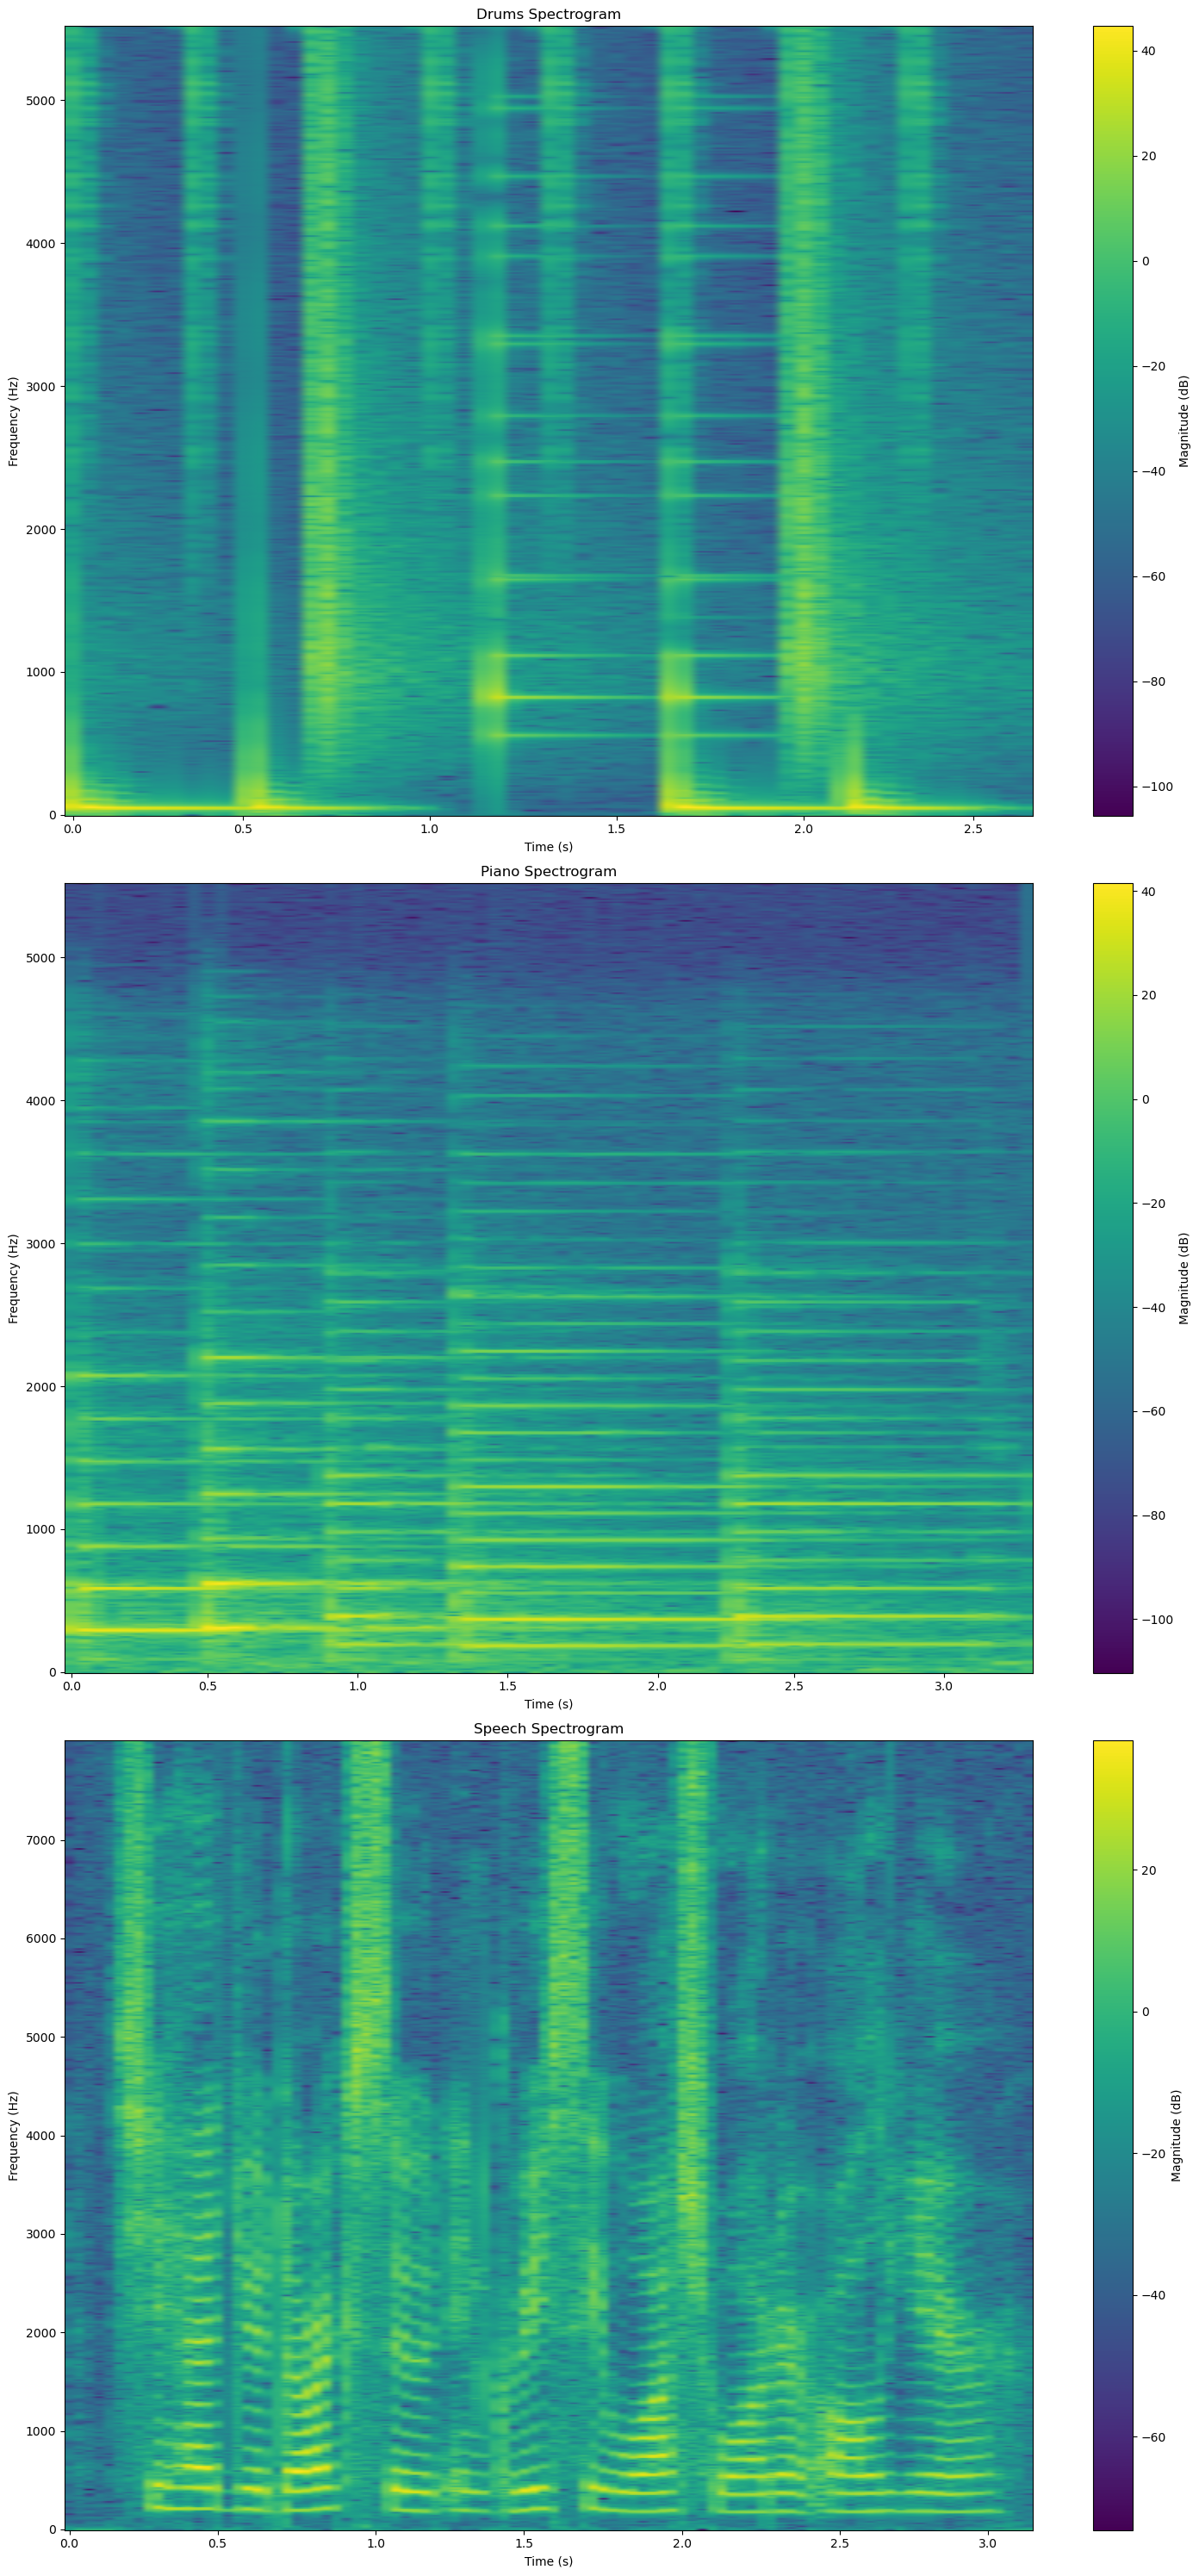

In [76]:
def stft( input_sound, dft_size, hop_size, window):
    # Use indexing to avoid loops. Hint: use np.lib.stride_tricks.as_strided
    i = np.arange( dft_size)[:,None] + np.arange( 0, len( input_sound)-dft_size, hop_size)[None,:]
    return np.fft.rfft( window[:,None] * input_sound[i], axis=0)
    # # YOUR CODE HERE
    # raise NotImplementedError()

stft_drums = stft(drums_padded, dft_size, hop_size, np.hanning(dft_size)**.5)
stft_piano = stft(piano_padded, dft_size, hop_size, np.hanning(dft_size)**.5)
stft_speech = stft(speech_padded, dft_size, hop_size, np.hanning(dft_size)**.5)


# Show me an example spectrogram
# raise NotImplementedError()

plt.figure(figsize=(15, 30))
plt.subplot(3, 1, 1)
plt.title('Drums Spectrogram')
plt.imshow(20 * np.log10(np.abs(stft_drums) + 1e-6), aspect='auto', origin='lower', cmap='viridis')
plt.xticks([(xtick_period*i*sr_drum)//hop_size for i in range(np.int32((drums.shape[0]/sr_drum)/xtick_period)+1)], [xtick_period*i for i in range(np.int32((drums.shape[0]/sr_drum)/xtick_period+1))])
plt.xlabel('Time (s)')
plt.yticks([i/(sr_drum/2)*dft_size/2 for i in range(0, sr_drum//2, 1000)], [i for i in range(0, sr_drum//2, 1000)])
plt.ylabel('Frequency (Hz)')
plt.colorbar(label='Magnitude (dB)')
plt.subplot(3, 1, 2)
plt.title('Piano Spectrogram')
plt.imshow(20 * np.log10(np.abs(stft_piano) + 1e-6), aspect='auto', origin='lower', cmap='viridis')
plt.xticks([(xtick_period*i*sr_piano)//hop_size for i in range(np.int32((piano.shape[0]/sr_piano)/xtick_period)+1)], [xtick_period*i for i in range(np.int32((piano.shape[0]/sr_piano)/xtick_period+1))])
plt.xlabel('Time (s)')
plt.yticks([i/(sr_piano/2)*dft_size/2 for i in range(0, sr_piano//2, 1000)], [i for i in range(0, sr_piano//2, 1000)])
plt.ylabel('Frequency (Hz)')
plt.colorbar(label='Magnitude (dB)')
plt.subplot(3, 1, 3)    
plt.title('Speech Spectrogram')
plt.imshow(20 * np.log10(np.abs(stft_speech) + 1e-6), aspect='auto', origin='lower', cmap='viridis')
plt.xticks([(xtick_period*i*sr_speech)//hop_size for i in range(np.int32((speech.shape[0]/sr_speech)/xtick_period)+1)], [xtick_period*i for i in range(np.int32((speech.shape[0]/sr_speech)/xtick_period+1))])
plt.xlabel('Time (s)')
plt.yticks([i/(sr_speech/2)*dft_size/2 for i in range(0, sr_speech//2, 1000)], [i for i in range(0, sr_speech//2, 1000)])
plt.ylabel('Frequency (Hz)')
plt.colorbar(label='Magnitude (dB)')
plt.tight_layout()

## Part 2. The Inverse Transform

We will now implement a function that accepts the output of the function above, and returns the time-domain waveform that produces it. This is known as an inverse Short-Time Fourier Transform. This function will look as follows:

```
    waveform = istft( stft_output, dft_size, hop_size, window)
		stft_output is the 2d array produced by the function you just did in part 1.
		dft_size is the DFT point size that you will use for the resynthesis.
		hop_size is the number of samples that your synthesis frames will advance.
		window is a vector containing the synthesis window that you will be using.
```

To perform the inverse transform you need to complete the following steps.

- Take each spectrum produced by the analysis and perform an inverse DFT on it. For each spectrum you should get back a small snippet of sound that was part of the original input.

- If the hop size you used is the same as the DFT size, you can simply concatenate the waveforms from above and that could recreate the original input (if you didn’t use a window). However since the waveforms in the analysis frames are likely to overlap (which happens when the hop size is smaller than the DFT size), you will need to use an overlap-add procedure. Generate an output array which is as long as the desired output sound and set all its elements to zero. Each time you obtain a waveform frame by applying the inverse DFT on a spectrum from step 1, you will need to add the result at the indices from which the original frame input came. This will effectively superimpose parts of frames that overlap and thus not throw away any information.

- Finally you will need to add the option of a synthesis window. Some of the operations that we will be performing in this STFT space (we'll see more in the future) will result in significant changes in the time domain and might create some discontinuities at the ends of the outputs which will result in audible clicks. A good way to ensure that these artifacts go away is to use a synthesis window. This will be a function defined as before, but we will be applying it on the time-domain output of the inverse DFT.

Using the same sounds as above, verify that when you perform a forward transform and then take its inverse, that you get an output that sounds like the original (there might be minor numerical differences, you can ignore these). Try to get the resynthesized output to be as close to the input as possible, when using various settings.

Note that you can’t always get perfect reconstruction depending on the parameters you choose. 
- The hop size needs to be equal or smaller than the DFT size otherwise you will lose information (some samples won’t be transformed). 
- When you use a window, you also cause some information to be lost. In the case of the Hann window you should have an overlap of 1/2, 1/4, 1/8, etc. of the DFT size. If not you will get an unintended amplitude modulation. 
- Likewise, if you use a Hann synthesis window, you are essencially applying the Hann window twice. In other words, you are applying the element-wise squared version of the window, which will mess up all the nice property of the Hann window. 
- A sneaky way to guarantee is to select a window, and square root its components before you apply it.  If the window is COLA, then this operation will guarantee that it will still result in a constant modulation once you apply it for both analysis and synthesis.  An easy way to check that COLA holds is to use a constant input signal (e.g. just ones) and see if you get a constant output when you resythesize.  If you see some wobbling in the output, then you know that COLA is not holding.
- The other way is to reduce the hop size to 1/4 or 1/8 of the DFT size. The excessive overlap with a right amount of shift can cancel out the unnecessary modulation.

Reconstructed Drums,Your browser does not support the audio element.


Reconstructed Piano,Your browser does not support the audio element.


Reconstructed Speech,Your browser does not support the audio element.


Reconstruction Error - Drums: 0.00018494808614472532, Piano: 0.00013004414465467477, Speech: 0.00011328513835604851


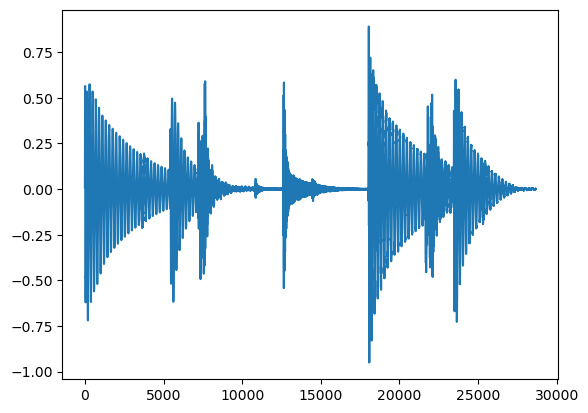

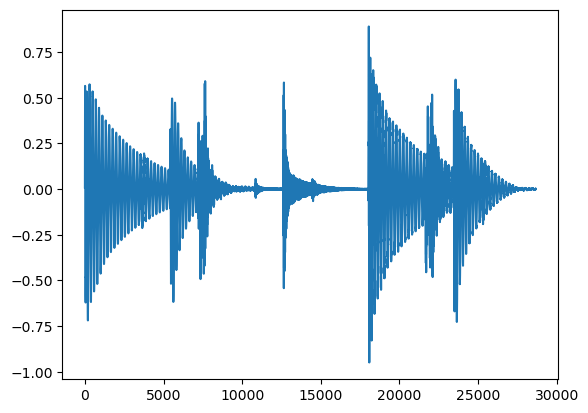

In [99]:
def istft( stft_output, dft_size, hop_size, window):
    """Compute the inverse short-time Fourier transform of a spectrogram.
    Args:
        stft_output: 2D numpy array (frequencies x time) containing the complex-valued STFT
        dft_size: Size of the DFT that was computed (number of frequency bins)
        hop_size: Number of samples advanced between successive frames
        window: 1D numpy array containing the synthesis window (length = dft_size)
    Returns:
        x: 1D numpy array containing the reconstructed sound samples
    """
    number_frames = stft_output.shape[1]
    output_length = (number_frames - 1) * hop_size + dft_size
    x = np.zeros(output_length)
    
    for frame in range(number_frames):
        start = frame * hop_size
        end = start + dft_size
        windowed_frame = np.fft.irfft(stft_output[:, frame], n=dft_size)
        x[start:end] += windowed_frame * window
    
    return x

# Invert all of the spectrograms from the previous assignment
# YOUR CODE HERE
reconstructed_drums = istft(stft_drums, dft_size, hop_size, np.hanning(dft_size)**.5)
reconstructed_piano = istft(stft_piano, dft_size, hop_size, np.hanning(dft_size)**.5)
reconstructed_speech = istft(stft_speech, dft_size, hop_size, np.hanning(dft_size)**.5)
# unpad the sounds to remove the zero-padding added earlier
reconstructed_drums = reconstructed_drums[512:-512]
reconstructed_piano = reconstructed_piano[512:-512]
reconstructed_speech = reconstructed_speech[512:-512]

# Play the sounds to make sure they are correct (look out for unwanted clicks, wobbles, etc.)
sound_player(reconstructed_drums, sr_drum, 'Reconstructed Drums')
sound_player(reconstructed_piano, sr_piano, 'Reconstructed Piano')
sound_player(reconstructed_speech, sr_speech, 'Reconstructed Speech')
# YOUR CODE HERE
# raise NotImplementedError()

# Measure your reconstruction error using the original inputs (should be tiny)
min_length = min(len(drums), len(reconstructed_drums))
drums = drums[:min_length]
reconstructed_drums = reconstructed_drums[:min_length]
min_length = min(len(piano), len(reconstructed_piano))
piano = piano[:min_length]
reconstructed_piano = reconstructed_piano[:min_length]
min_length = min(len(speech), len(reconstructed_speech))
speech = speech[:min_length]
reconstructed_speech = reconstructed_speech[:min_length]
error_drums = np.std((drums - reconstructed_drums))
error_piano = np.std((piano - reconstructed_piano))
error_speech = np.std((speech - reconstructed_speech))
print(f'Reconstruction Error - Drums: {error_drums}, Piano: {error_piano}, Speech: {error_speech}')
# YOUR CODE HERE
# raise NotImplementedError()
plt.figure()
plt.plot(drums)
plt.figure()
plt.plot(reconstructed_drums)


(Optional) Once again, think about how to do this without for loops. Hint: you can use the ```np.add.at``` function.

Reconstructed Drums,Your browser does not support the audio element.


Reconstructed Piano,Your browser does not support the audio element.


Reconstructed Speech,Your browser does not support the audio element.


Reconstruction Error - Drums: 0.00018494808614472532, Piano: 0.00013004414465467477, Speech: 0.00011328513835604851


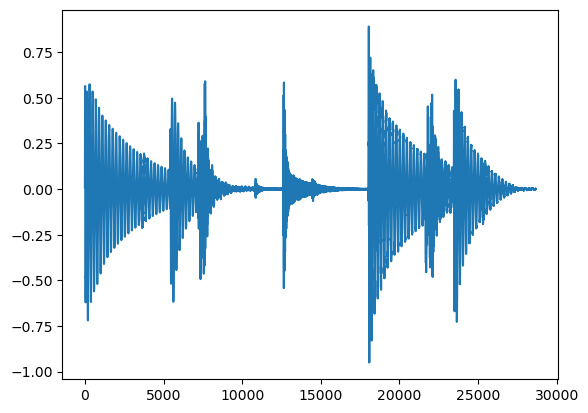

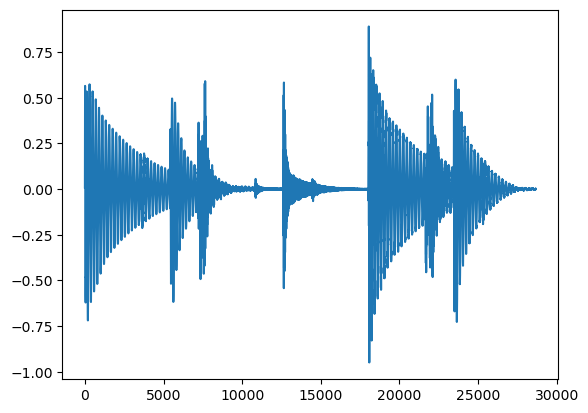

In [78]:

def istft( stft_output, dft_size, hop_size, window):
    # YOUR CODE HERE
    # raise NotImplementedError()
    x = window[:,None] * np.fft.irfft( stft_output, axis=0)
    i = np.arange( dft_size)[:,None] + np.arange( 0, stft_output.shape[-1]*hop_size, hop_size)[None,:]
    z = np.zeros( x.shape[1]*hop_size + dft_size)
    np.add.at( z, i.reshape(-1), x.reshape(-1))
    return z * (2*hop_size/dft_size)

# Show me examples of reconstructed sounds
# raise NotImplementedError()

reconstructed_drums = istft(stft_drums, dft_size, hop_size, np.hanning(dft_size)**.5)
reconstructed_piano = istft(stft_piano, dft_size, hop_size, np.hanning(dft_size)**.5)
reconstructed_speech = istft(stft_speech, dft_size, hop_size, np.hanning(dft_size)**.5)
# unpad the sounds to remove the zero-padding added earlier
reconstructed_drums = reconstructed_drums[512:-512]
reconstructed_piano = reconstructed_piano[512:-512]
reconstructed_speech = reconstructed_speech[512:-512]

# Play the sounds to make sure they are correct (look out for unwanted clicks, wobbles, etc.)
sound_player(reconstructed_drums, sr_drum, 'Reconstructed Drums')
sound_player(reconstructed_piano, sr_piano, 'Reconstructed Piano')
sound_player(reconstructed_speech, sr_speech, 'Reconstructed Speech')
# YOUR CODE HERE
# raise NotImplementedError()

# Measure your reconstruction error using the original inputs (should be tiny)
min_length = min(len(drums), len(reconstructed_drums))
drums = drums[:min_length]
reconstructed_drums = reconstructed_drums[:min_length]
min_length = min(len(piano), len(reconstructed_piano))
piano = piano[:min_length]
reconstructed_piano = reconstructed_piano[:min_length]
min_length = min(len(speech), len(reconstructed_speech))
speech = speech[:min_length]
reconstructed_speech = reconstructed_speech[:min_length]
error_drums = np.std((drums - reconstructed_drums))
error_piano = np.std((piano - reconstructed_piano))
error_speech = np.std((speech - reconstructed_speech))
print(f'Reconstruction Error - Drums: {error_drums}, Piano: {error_piano}, Speech: {error_speech}')
# YOUR CODE HERE
# raise NotImplementedError()
plt.figure()
plt.plot(drums)
plt.figure()
plt.plot(reconstructed_drums)

## Part 3. An Application

Just so you get an idea of how one might use these tools here is a simple example. Take one of the test sounds above and add to it a constant sinusoid with a frequency of 1kHz. When you plot the spectrogram of that sound you should be able to see the sinusoid. Using your code take the spectrogram matrix and set its values that correspond to the sinusoid to zero. Put that back to the inverse stft function and you should get a denoised version of the signal. FYI, this is not a textbook way to solve this problem (it's a little hacky), we'll cover the right way later.

Mix of Drums and 1kHz Sinusoid,Your browser does not support the audio element.


Mix after Removing 1kHz Sinusoid,Your browser does not support the audio element.


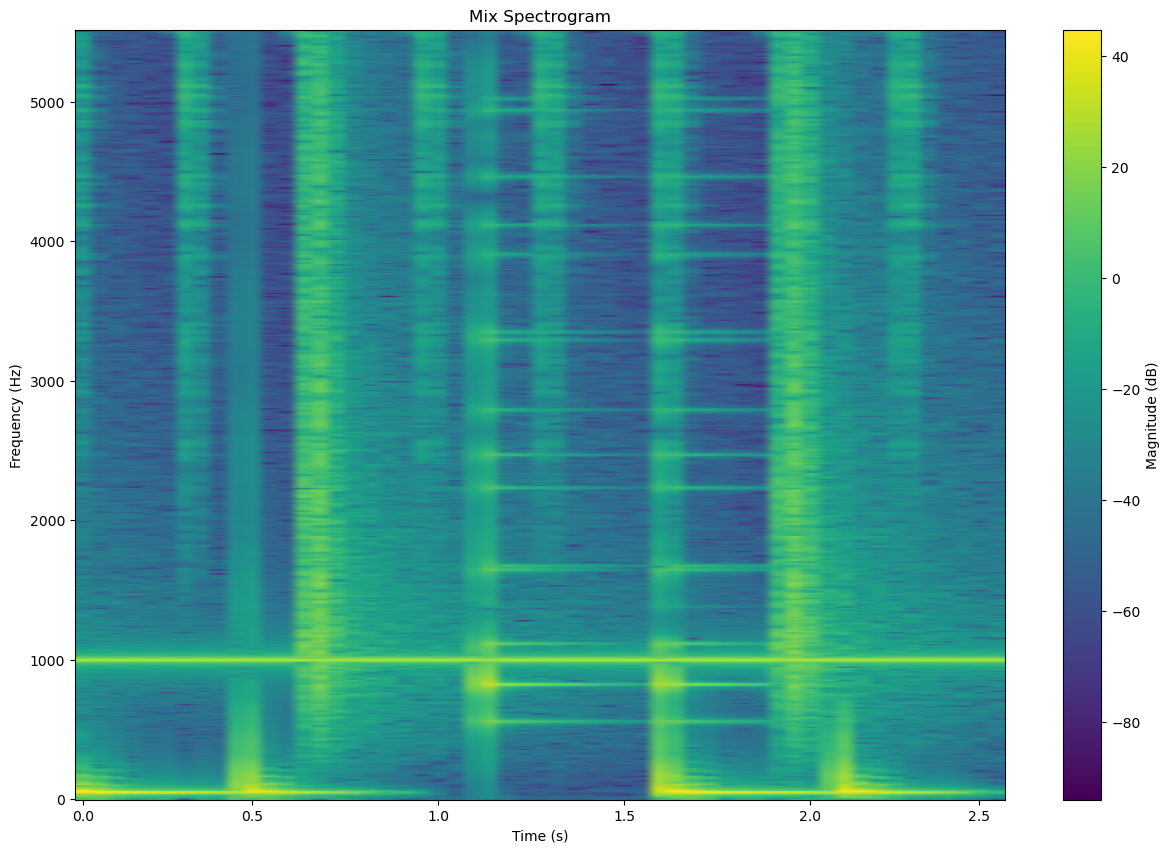

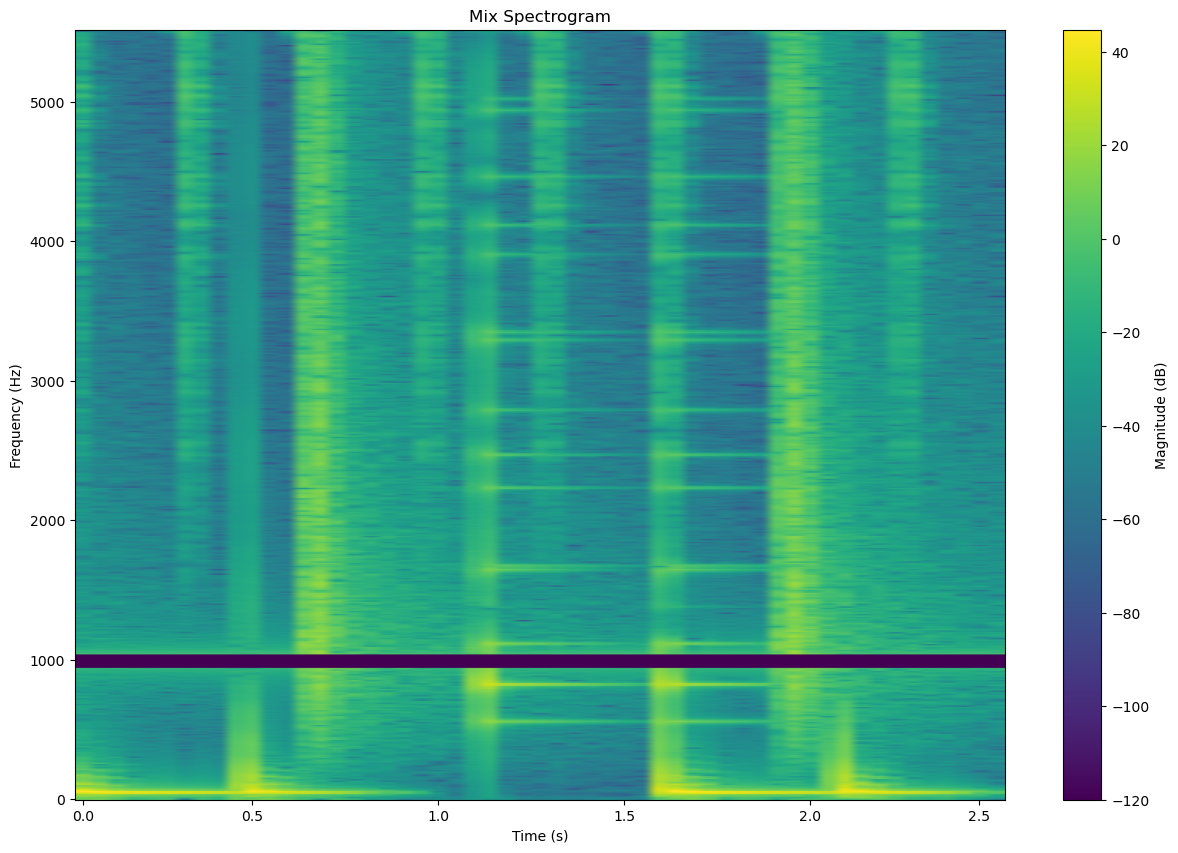

In [88]:
# Load one sound and add to it a 1kHz sinusoid of the same length
drums, sr_drum=sf.read('80s.wav')
piano, sr_piano=sf.read('piano.wav')
speech, sr_speech=sf.read('speech.wav')

duration=len(drums)/sr_drum
t = np.linspace(0, duration, int(sr_drum * duration), endpoint=False)
sinusoid = 0.1 * np.sin(2 * np.pi * 1000 * t)

mix = drums + sinusoid

# Check out the mix; do you hear both sounds?
sound_player(mix, sr_drum, 'Mix of Drums and 1kHz Sinusoid')
# Plot the spectrogram of the mix and verify that you can see both sounds
# YOUR CODE HERE
# raise NotImplementedError()
stft_mix = stft(mix, dft_size, hop_size, np.hanning(dft_size)**.5)
plt.figure(figsize=(15, 10))
plt.title('Mix Spectrogram')
plt.imshow(20 * np.log10(np.abs(stft_mix) + 1e-6), aspect='auto', origin='lower', cmap='viridis')
plt.xticks([(xtick_period*i*sr_drum)//hop_size for i in range(np.int32((mix.shape[0]/sr_drum)/xtick_period)+1)], [xtick_period*i for i in range(np.int32((mix.shape[0]/sr_drum)/xtick_period+1))])
plt.xlabel('Time (s)')
plt.yticks([i/(sr_drum/2)*dft_size/2 for i in range(0, sr_drum//2, 1000)], [i for i in range(0, sr_drum//2, 1000)])
plt.ylabel('Frequency (Hz)')
plt.colorbar(label='Magnitude (dB)')

# Set selected spectrogram values to 0 to "erase" the sinusoid

# YOUR CODE HERE
# raise NotImplementedError()
# Create a copy of the mix STFT to modify
stft_mix_modified = np.copy(stft_mix)
# Zero out frequency bins around 1kHz
freq_bin_1kHz = int(1000 * dft_size / sr_drum)
stft_mix_modified[freq_bin_1kHz-4:freq_bin_1kHz+5, :] = 0 

plt.figure(figsize=(15, 10))
plt.title('Mix Spectrogram')
plt.imshow(20 * np.log10(np.abs(stft_mix_modified) + 1e-6), aspect='auto', origin='lower', cmap='viridis')
plt.xticks([(xtick_period*i*sr_drum)//hop_size for i in range(np.int32((mix.shape[0]/sr_drum)/xtick_period)+1)], [xtick_period*i for i in range(np.int32((mix.shape[0]/sr_drum)/xtick_period+1))])
plt.xlabel('Time (s)')
plt.yticks([i/(sr_drum/2)*dft_size/2 for i in range(0, sr_drum//2, 1000)], [i for i in range(0, sr_drum//2, 1000)])
plt.ylabel('Frequency (Hz)')
plt.colorbar(label='Magnitude (dB)')



# Use your inverse STFT routine to get a playable waveform
istft_mix_modified = istft(stft_mix_modified, dft_size, hop_size, np.hanning(dft_size)**.5)
sound_player(istft_mix_modified, sr_drum, 'Mix after Removing 1kHz Sinusoid')
# YOUR CODE HERE
# raise NotImplementedError()

## Part 4. Just for fun

Load ```face.png```in python.  Here's how it looks like. 
![alt text](face.png)
Pretend it is a spectrogram and put it into your inverse STFT function to get it's correspoding waveform.  Imagine how it's going to sound like before you run it!

```matplotlib.pyplot.imread``` to load an image from a file or a URL directly.  Note that in the case of color images this will return a 3D array (x/y/color) or 4D if it includes the "alpha" channel for transparency.  You can take the average of the color (third) dimension to get a 2D array, which will be a grayscale version of the image and can be used as an input to your istft routine.

In [104]:
# Get an image loaded
face=plt.imread('face.png')
print(np.max(face))
print(np.shape(face))
# raise NotImplementedError()



face_wav=istft( np.sum(face, axis=2), 512, 256, np.hanning(512))


# Make a sound out of it
# raise NotImplementedError()

# Listen to the beautiful sound!
sound_player(face_wav, 8000, 'Sound from Image')

1.0
(257, 256, 4)


Sound from Image,Your browser does not support the audio element.


## Part 4. (optional): Just for fun

You may have found the previous example weird as it's missing the phase portion entirely. It still made sense as it sounds like the figure (to my ears). What's going to happen if you mess up the phase portion then? Let's play around with one of the three examples in the first question. Load one of them, and take the magnitudes like you did to draw them. Now, synthesize a random phase matrix of the same size as the magnitude matrix. Combine them to make a complex spectrogram, and put that into your inverse STFT routine. How does it sound like? 

In [113]:
dft_size=1024
hop_size=512

# Load each sound
drums, sr_drum=sf.read('80s.wav')
piano, sr_piano=sf.read('piano.wav')
speech, sr_speech=sf.read('speech.wav')


# zero-pad the beginning and end of each sound by 512 samples
drums_padded = np.pad(drums, (512, 512), mode='constant')
piano_padded = np.pad(piano, (512, 512), mode='constant')
speech_padded = np.pad(speech, (512, 512), mode='constant')

# STFT them
stft_drums = stft(drums_padded, dft_size, hop_size, np.hanning(dft_size)**.5)
stft_piano = stft(piano_padded, dft_size, hop_size, np.hanning(dft_size)**.5)
stft_speech = stft(speech_padded, dft_size, hop_size, np.hanning(dft_size)**.5)

stft_drums_mags = np.abs(stft_drums)
stft_piano_mags = np.abs(stft_piano)
stft_speech_mags = np.abs(stft_speech)


stft_drums_phase=np.random.rand(stft_drums.shape[0], stft_drums.shape[1])*2*np.pi
stft_piano_phase=np.random.rand(stft_piano.shape[0], stft_piano.shape[1])*2*np.pi
stft_speech_phase=np.random.rand(stft_speech.shape[0], stft_speech.shape[1])*2*np.pi

# change into complex representation
stft_drums_phases =  np.exp(1j*stft_drums_phase)
stft_piano_phases =  np.exp(1j*stft_piano_phase)
stft_speech_phases =  np.exp(1j*stft_speech_phase)

stft_drums_phases = stft_drums_mags*stft_drums_phases
stft_piano_phases = stft_piano_mags*stft_piano_phases
stft_speech_phases = stft_speech_mags*stft_speech_phases

drums_reconstructed = istft(stft_drums_phases, dft_size, hop_size, np.hanning(dft_size)**.5)
piano_reconstructed = istft(stft_piano_phases, dft_size, hop_size, np.hanning(dft_size)**.5)
speech_reconstructed = istft(stft_speech_phases, dft_size, hop_size, np.hanning(dft_size)**.5)
# unpad the sounds to remove the zero-padding added earlier
drums_reconstructed = drums_reconstructed[512:-512]
piano_reconstructed = piano_reconstructed[512:-512]
speech_reconstructed = speech_reconstructed[512:-512]


sound_player(drums_reconstructed, sr_drum, 'Random Phase Drums')
sound_player(piano_reconstructed, sr_piano, 'Random Phase Piano')
sound_player(speech_reconstructed, sr_speech, 'Random Phase Speech')

Random Phase Drums,Your browser does not support the audio element.


Random Phase Piano,Your browser does not support the audio element.


Random Phase Speech,Your browser does not support the audio element.
